PRIMO LIVELLO DI ANALISI: GRAFICO A BARRE SLOW, AVERAGE, FAST 

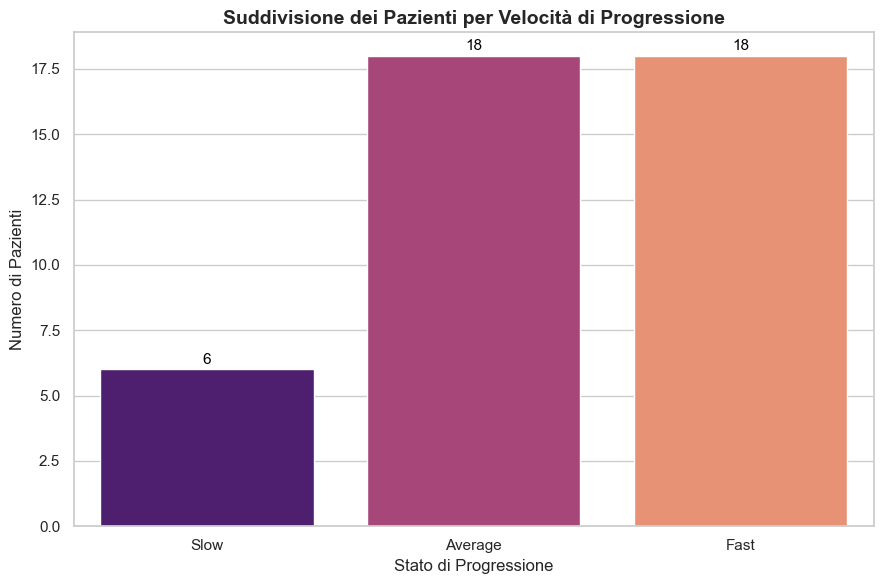

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel('TABELLAANALISI2.xlsx')

# 2. CALCOLO PROGRESSION RATE
# Usiamo i nomi delle colonne presenti nel dataset
df['Progression_Rate'] = df['UPDRS_3_TOT'] / df['Anni_Diagnosi']

# 3. SEGMENTAZIONE
def segmenta(rate):
    if rate < 2: return 'Slow'
    elif rate <= 5: return 'Average'
    else: return 'Fast'

df['Group'] = df['Progression_Rate'].apply(segmenta)


sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# Definizione dell'ordine delle categorie per coerenza clinica
ordine = ['Slow', 'Average', 'Fast']

# Creazione del grafico a barre delle frequenze
ax = sns.countplot(x='Group', data=df, order=ordine, palette='magma')

# Aggiunta dei titoli 
plt.title('Suddivisione dei Pazienti per Velocità di Progressione', fontsize=14, fontweight='bold')
plt.xlabel('Stato di Progressione', fontsize=12)
plt.ylabel('Numero di Pazienti', fontsize=12)

# Aggiunta dei conteggi esatti sopra ogni barra per una lettura immediata
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=11, color='black', 
                xytext=(0, 7), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

BOX PLOT PRIMA STRATIFICAZIONE

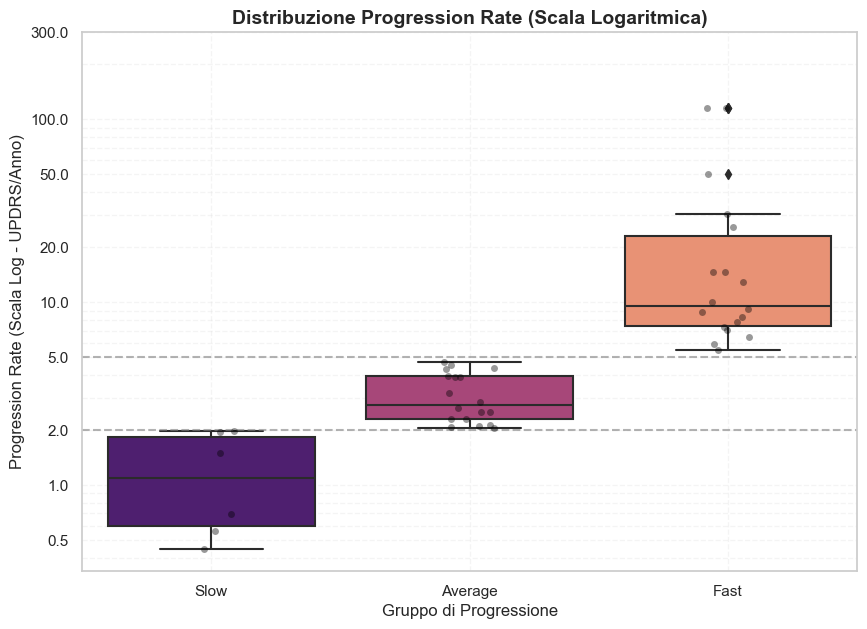

In [4]:
# BOX PLOT IN SCALA LOG 

plt.figure(figsize=(10, 7))

# Creazione del Box Plot con scala logaritmica sull'asse Y
# Usiamo log_scale=True per distribuire meglio i dati
ax = sns.boxplot(x='Group', y='Progression_Rate', data=df, 
                 order=['Slow', 'Average', 'Fast'], palette='magma')

# Aggiungiamo i punti per vedere la densità 
sns.stripplot(x='Group', y='Progression_Rate', data=df, 
              order=['Slow', 'Average', 'Fast'], 
              color='black', alpha=0.4, jitter=True)

# IMPOSTAZIONE SCALA LOGARITMICA
plt.yscale('log')

# Aggiungiamo linee di riferimento per i cut-off (2 e 5)
plt.axhline(y=2, color='grey', linestyle='--', alpha=0.6)
plt.axhline(y=5, color='grey', linestyle='--', alpha=0.6)

plt.title('Distribuzione Progression Rate (Scala Logaritmica)', fontsize=14, fontweight='bold')
plt.xlabel('Gruppo di Progressione', fontsize=12)
plt.ylabel('Progression Rate (Scala Log - UPDRS/Anno)', fontsize=12)

# Pulizia asse Y: mostriamo valori leggibili invece di potenze di 10
from matplotlib.ticker import ScalarFormatter
ax.yaxis.set_major_formatter(ScalarFormatter())
plt.yticks([0.5, 1, 2, 5, 10, 20, 50, 100, 300])

plt.grid(True, which="both", ls="--", alpha=0.2)
plt.show()

HEATMAP DI CORRELAZIONE

Righe usate per la correlazione: 42 su 42

NaN nella matrice di correlazione:
0 celle NaN
                  Progression Rate   Età  Sesso (M=1, F=0)  UPDRS III Tot.  \
Progression Rate              1.00  0.01              0.21            0.30   
Età                           0.01  1.00              0.70           -0.33   
Sesso (M=1, F=0)              0.21  0.70              1.00            0.02   
UPDRS III Tot.                0.30 -0.33              0.02            1.00   
Anni Diagnosi                -0.90 -0.19             -0.30            0.07   
Hoehn & Yahr                  0.06 -0.27             -0.16            0.40   

                  Anni Diagnosi  Hoehn & Yahr  
Progression Rate          -0.90          0.06  
Età                       -0.19         -0.27  
Sesso (M=1, F=0)          -0.30         -0.16  
UPDRS III Tot.             0.07          0.40  
Anni Diagnosi              1.00          0.09  
Hoehn & Yahr               0.09          1.00  


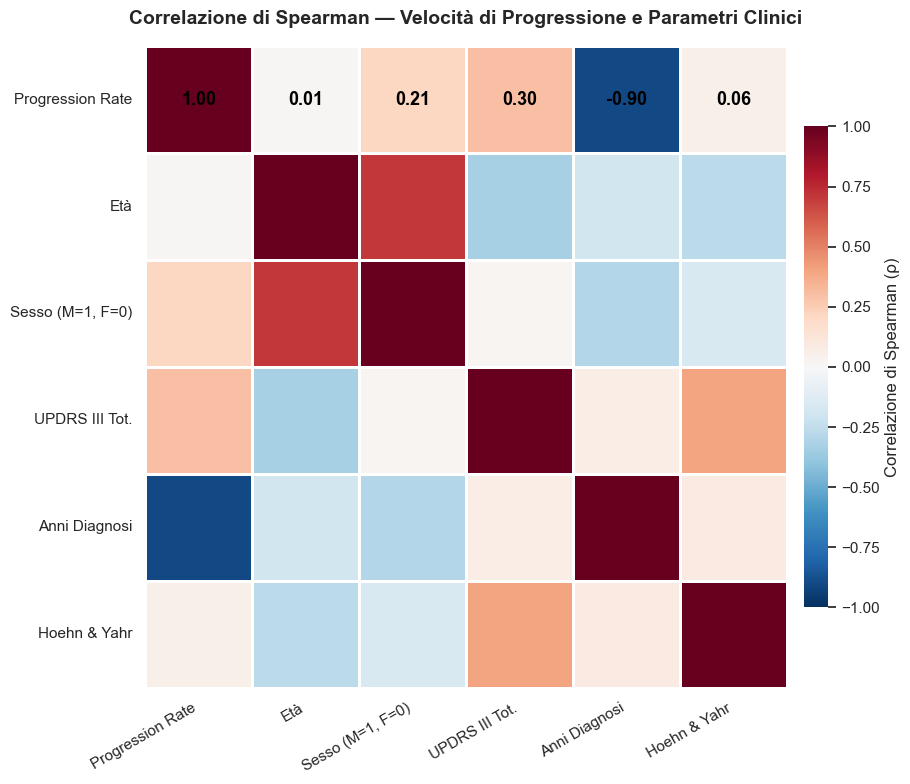

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preparazione variabili 
if df['Sesso'].dtype == 'object':
    df['Sessocod'] = df['Sesso'].map({'Male': 1, 'Female': 0})
else:
    df['Sessocod'] = df['Sesso']

colonne_heatmap = [
    'Progression_Rate',
    'Eta',
    'Sessocod',
    'UPDRS_3_TOT',
    'Anni_Diagnosi',
    'Hoehn_Yahr'
]

label_map = {
    'Progression_Rate': 'Progression Rate',
    'Eta':              'Età',
    'Sessocod':         'Sesso (M=1, F=0)',
    'UPDRS_3_TOT':      'UPDRS III Tot.',
    'Anni_Diagnosi':    'Anni Diagnosi',
    'Hoehn_Yahr':       'Hoehn & Yahr'
}

#Verifica che non ci siano NaN (valori vuoti o non definiti nel dataset)
df_clean = df[colonne_heatmap].dropna()
print(f"Righe usate per la correlazione: {len(df_clean)} su {len(df)}")

# Calcolo correlazione 
corr_matrix = df_clean.corr(method='spearman')
corr_matrix = corr_matrix.rename(index=label_map, columns=label_map)

# Verifica che la matrice non abbia NaN 
print("\nNaN nella matrice di correlazione:")
print(corr_matrix.isnull().sum().sum(), "celle NaN")
print(corr_matrix.round(2))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    annot_kws={
        'size': 13,
        'weight': 'bold'
    },
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=1,
    linecolor='white',
    square=True,
    cbar_kws={
        'shrink': 0.75,
        'label': 'Correlazione di Spearman (ρ)',
        'pad': 0.02
    },
    ax=ax
)

# Caratteri del testo
for text in ax.texts:
    text.set_color('black')
    text.set_fontsize(13)
    text.set_fontweight('bold')

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

ax.set_title(
    'Correlazione di Spearman — Velocità di Progressione e Parametri Clinici',
    fontsize=14,
    fontweight='bold',
    pad=16
)

plt.tight_layout()
plt.savefig('heatmap_correlazione.png', dpi=150, bbox_inches='tight')
plt.show()

ANALISI, REGRESSIONI

=== Distribuzione classi ===
  Slow (<2): 6 pazienti (14.3%)
  Average (2-5): 18 pazienti (42.9%)
  Fast (>5): 18 pazienti (42.9%)

REGRESSIONE LINEARE: Progression Rate ~ Anni Diagnosi
                            OLS Regression Results                            
Dep. Variable:       Progression_Rate   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.181
Method:                 Least Squares   F-statistic:                     10.05
Date:                Wed, 24 Jun 2026   Prob (F-statistic):            0.00292
Time:                        13:27:03   Log-Likelihood:                -189.74
No. Observations:                  42   AIC:                             383.5
Df Residuals:                      40   BIC:                             387.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef

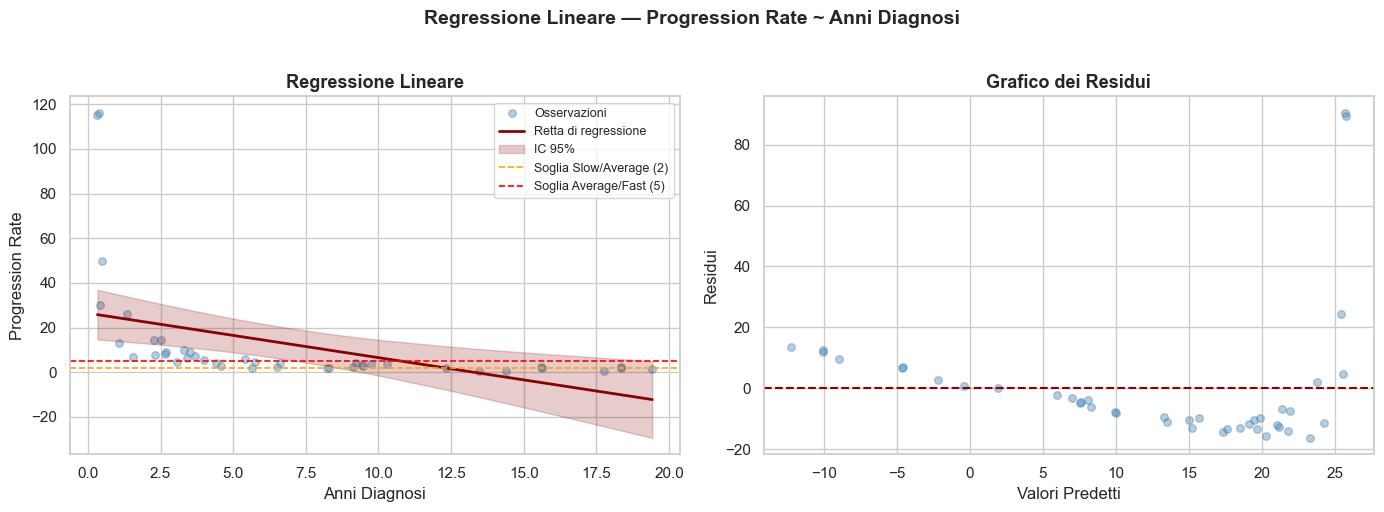


R²                        : 0.201
Coefficiente Anni_Diagnosi: -1.9909
p-value                   : 0.0029

REGRESSIONE MULTINOMIALE: Slow / Average / Fast ~ Anni Diagnosi
Optimization terminated successfully.
         Current function value: 0.360221
         Iterations 10
                          MNLogit Regression Results                          
Dep. Variable:       Progression_Rate   No. Observations:                   42
Model:                        MNLogit   Df Residuals:                       38
Method:                           MLE   Df Model:                            2
Date:                Wed, 24 Jun 2026   Pseudo R-squ.:                  0.6413
Time:                        13:27:05   Log-Likelihood:                -15.129
converged:                       True   LL-Null:                       -42.178
Covariance Type:            nonrobust   LLR p-value:                 1.790e-12
Progression_Rate=1       coef    std err          z      P>|z|      [0.025      0.975]
-------

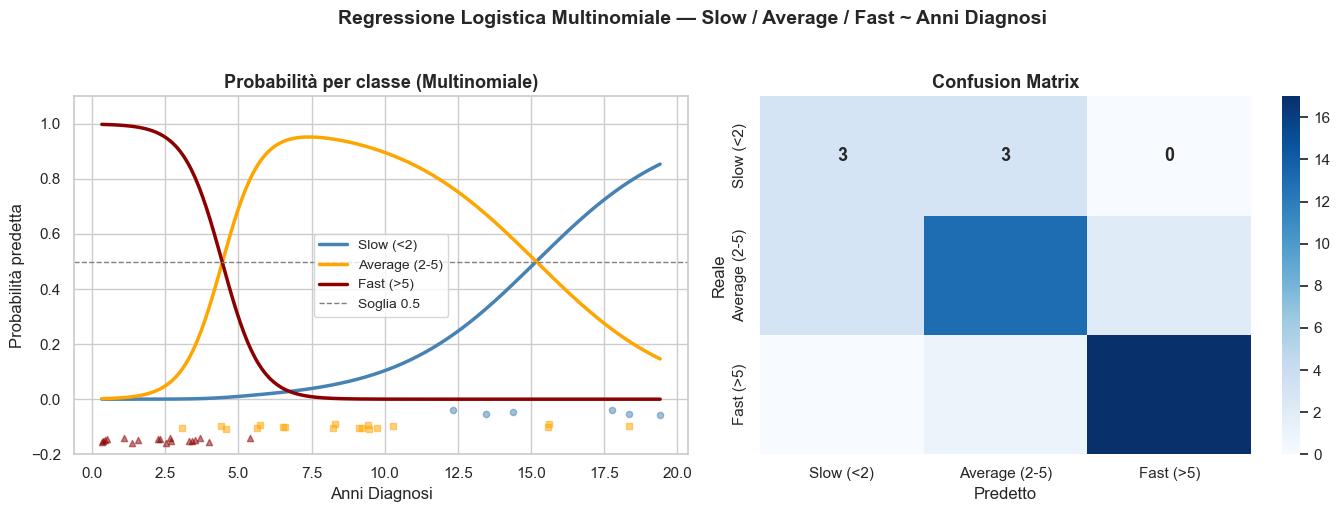


--- Classification Report ---
               precision    recall  f1-score   support

    Slow (<2)       0.50      0.50      0.50         6
Average (2-5)       0.76      0.72      0.74        18
    Fast (>5)       0.89      0.94      0.92        18

     accuracy                           0.79        42
    macro avg       0.72      0.72      0.72        42
 weighted avg       0.78      0.79      0.78        42



In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import MNLogit
import warnings
warnings.filterwarnings('ignore')

# PREPARAZIONE DATI che voglio utilizzare

df_clean = df[['Progression_Rate', 'Anni_Diagnosi']].dropna()

X = df_clean['Anni_Diagnosi']
y_cont = df_clean['Progression_Rate']

# soglie cliniche
def classifica_progressione(rate):
    if rate < 2:
        return 0   # Slow
    elif rate <= 5:
        return 1   # Average
    else:
        return 2   # Fast

y_multi = y_cont.apply(classifica_progressione)

print("=== Distribuzione classi ===")
conteggi = y_multi.value_counts().sort_index()
labels_map = {0: 'Slow (<2)', 1: 'Average (2-5)', 2: 'Fast (>5)'}
for k, v in conteggi.items():
    print(f"  {labels_map[k]}: {v} pazienti ({v/len(y_multi)*100:.1f}%)")


# REGRESSIONE LINEARE (invariata, Progression Rate continuo)

print("\n" + "="*55)
print("REGRESSIONE LINEARE: Progression Rate ~ Anni Diagnosi")
print("="*55)

X_sm = sm.add_constant(X)
model_lin = sm.OLS(y_cont, X_sm).fit()
print(model_lin.summary())

pred_lin = model_lin.get_prediction(X_sm)
pred_df = pred_lin.summary_frame(alpha=0.05)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(X, y_cont, alpha=0.4, color='steelblue', s=30, label='Osservazioni')
sort_idx = X.argsort()
ax.plot(X.iloc[sort_idx], pred_df['mean'].iloc[sort_idx], color='darkred', linewidth=2, label='Retta di regressione')
ax.fill_between(X.iloc[sort_idx],
                pred_df['mean_ci_lower'].iloc[sort_idx],
                pred_df['mean_ci_upper'].iloc[sort_idx],
                alpha=0.2, color='darkred', label='IC 95%')
ax.axhline(2, color='orange', linestyle='--', linewidth=1.2, label='Soglia Slow/Average (2)')
ax.axhline(5, color='red', linestyle='--', linewidth=1.2, label='Soglia Average/Fast (5)')
ax.set_xlabel('Anni Diagnosi', fontsize=12)
ax.set_ylabel('Progression Rate', fontsize=12)
ax.set_title('Regressione Lineare', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

ax2 = axes[1]
residui = model_lin.resid
ax2.scatter(model_lin.fittedvalues, residui, alpha=0.4, color='steelblue', s=30)
ax2.axhline(0, color='darkred', linewidth=1.5, linestyle='--')
ax2.set_xlabel('Valori Predetti', fontsize=12)
ax2.set_ylabel('Residui', fontsize=12)
ax2.set_title('Grafico dei Residui', fontsize=13, fontweight='bold')

plt.suptitle('Regressione Lineare — Progression Rate ~ Anni Diagnosi',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('regressione_lineare.png', dpi=150, bbox_inches='tight')
plt.show()

r2 = model_lin.rsquared
coef = model_lin.params['Anni_Diagnosi']
pval = model_lin.pvalues['Anni_Diagnosi']
print(f"\nR²                        : {r2:.3f}")
print(f"Coefficiente Anni_Diagnosi: {coef:.4f}")
print(f"p-value                   : {pval:.4f}")


# REGRESSIONE LOGISTICA MULTINOMIALE

print("\n" + "="*55)
print("REGRESSIONE MULTINOMIALE: Slow / Average / Fast ~ Anni Diagnosi")
print("="*55)

# Categoria di riferimento = 0 (Slow) — le altre si confrontano con essa
model_mn = MNLogit(y_multi, X_sm).fit()
print(model_mn.summary())

# Odds Ratio per ogni classe vs Slow
print("\n--- Odds Ratio (IC 95%) vs categoria Slow ---")
params = model_mn.params
conf = model_mn.conf_int()
for i, label in enumerate(['Average vs Slow', 'Fast vs Slow']):
    OR = np.exp(params.iloc[:, i])
    CI_low = np.exp(conf.iloc[i*2: i*2+2, 0])
    CI_high = np.exp(conf.iloc[i*2: i*2+2, 1])
    print(f"\n  {label}:")
    print(f"    OR  Anni_Diagnosi: {OR['Anni_Diagnosi']:.3f}")
    print(f"    IC 95%: [{np.exp(conf.iloc[i*2+1, 0]):.3f} – {np.exp(conf.iloc[i*2+1, 1]):.3f}]")


# PROBABILITÀ PREDETTE — curva per ogni classe

x_range = np.linspace(X.min(), X.max(), 300)
x_range_sm = sm.add_constant(x_range)
probs = model_mn.predict(x_range_sm)  # shape (300, 3)

colors = ['steelblue', 'orange', 'darkred']
class_labels = ['Slow (<2)', 'Average (2-5)', 'Fast (>5)']
markers = ['o', 's', '^']

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

ax3 = axes2[0]
for i in range(3):
    ax3.plot(x_range, probs[:, i], color=colors[i], linewidth=2.5, label=class_labels[i])

# Scatter osservazioni con jitter per ogni classe
for i in range(3):
    mask = y_multi == i
    ax3.scatter(X[mask],
                np.full(mask.sum(), -0.05 - i*0.05) + np.random.uniform(-0.01, 0.01, mask.sum()),
                color=colors[i], s=20, alpha=0.5, marker=markers[i])

ax3.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Soglia 0.5')
ax3.set_xlabel('Anni Diagnosi', fontsize=12)
ax3.set_ylabel('Probabilità predetta', fontsize=12)
ax3.set_title('Probabilità per classe (Multinomiale)', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.set_ylim(-0.2, 1.1)

# Confusion matrix
ax4 = axes2[1]
y_pred_class = np.array(model_mn.predict(X_sm)).argmax(axis=1)
cm = confusion_matrix(y_multi, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels,
            annot_kws={'size': 13, 'weight': 'bold'},
            ax=ax4)
ax4.set_xlabel('Predetto', fontsize=12)
ax4.set_ylabel('Reale', fontsize=12)
ax4.set_title('Confusion Matrix', fontsize=13, fontweight='bold')

plt.suptitle('Regressione Logistica Multinomiale — Slow / Average / Fast ~ Anni Diagnosi',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('regressione_multinomiale.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Classification Report ---")
print(classification_report(y_multi, y_pred_class, target_names=class_labels))

SECONDO LIVELLO DI ANALISI

In [7]:
# Creazione della funzione per la classificazione biomeccanica
def classifica_biomeccanica(row):
    # Velocità >= 80 E Lunghezza Passo >= 45
    if row['SelfPace_Velocity_cm_sec'] >= 80 and row['SelfPace_StepLength_Mean'] >= 45:
        return 'In Range (Mild/Mod)'
    else:
        # Se anche solo uno dei due cade sotto la soglia
        return 'Stadio 3 Strumentale'

# Applicazione al dataset
df['Stadio_Biomeccanico'] = df.apply(classifica_biomeccanica, axis=1)

# Vediamo quanti pazienti cadono in ogni categoria
print(df['Stadio_Biomeccanico'].value_counts())

Stadio_Biomeccanico
In Range (Mild/Mod)     36
Stadio 3 Strumentale     6
Name: count, dtype: int64


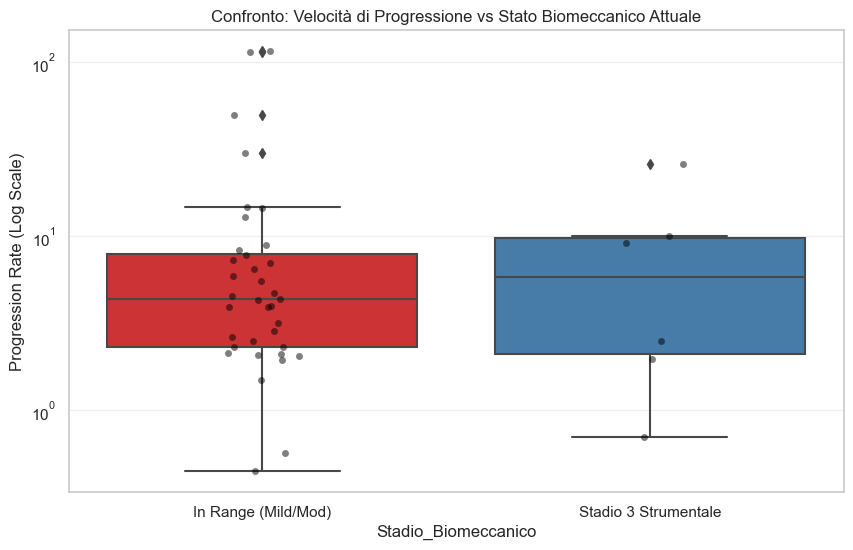

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Usiamo la scala logaritmica come abbiamo fatto per i gruppi Fast/Slow
ax = sns.boxplot(x='Stadio_Biomeccanico', y='Progression_Rate', data=df, palette='Set1')
ax.set_yscale('log') 

# punti per vedere i 43 pazienti singolarmente
sns.stripplot(x='Stadio_Biomeccanico', y='Progression_Rate', data=df, color='black', alpha=0.5)

plt.title('Confronto: Velocità di Progressione vs Stato Biomeccanico Attuale')
plt.ylabel('Progression Rate (Log Scale)')
plt.grid(axis='y', alpha=0.3)
plt.show()

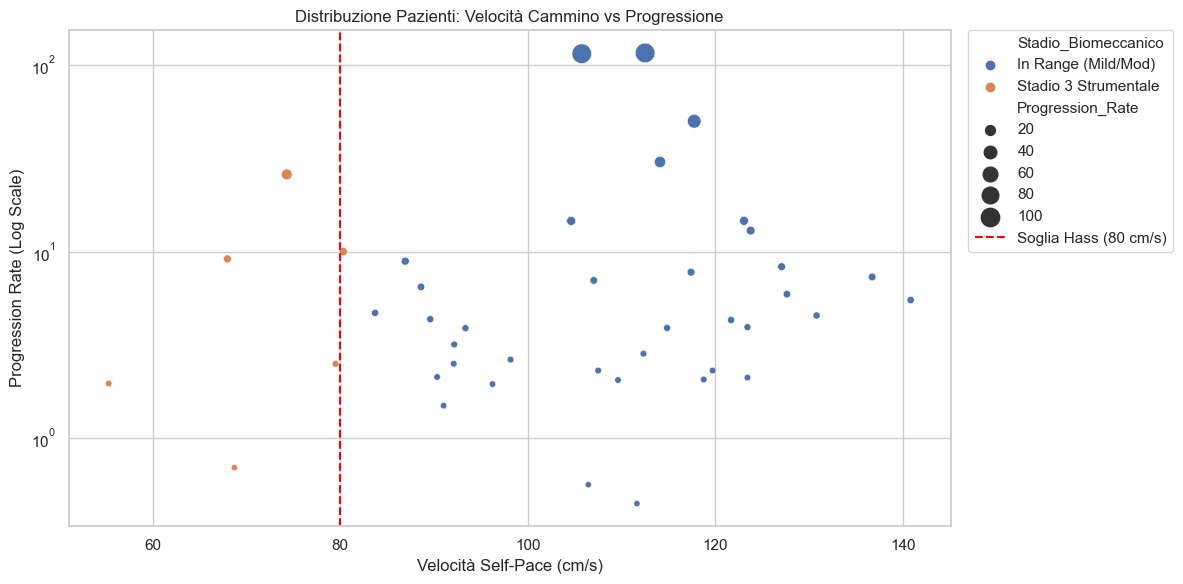

In [9]:
plt.figure(figsize=(12, 6)) # Aumentato leggermente la larghezza per far spazio alla legenda

sns.scatterplot(x='SelfPace_Velocity_cm_sec', y='Progression_Rate', 
                hue='Stadio_Biomeccanico', size='Progression_Rate', 
                sizes=(20, 200), data=df)

# Linea di cut-off
plt.axvline(x=80, color='red', linestyle='--', label='Soglia Hass (80 cm/s)')

plt.yscale('log')
plt.title('Distribuzione Pazienti: Velocità Cammino vs Progressione')
plt.xlabel('Velocità Self-Pace (cm/s)')
plt.ylabel('Progression Rate (Log Scale)')

# SPOSTAMENTO LEGENDA:
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout() # Aggiusta automaticamente gli spazi per non tagliare la legenda
plt.show()

TABELLA INCROCIATA

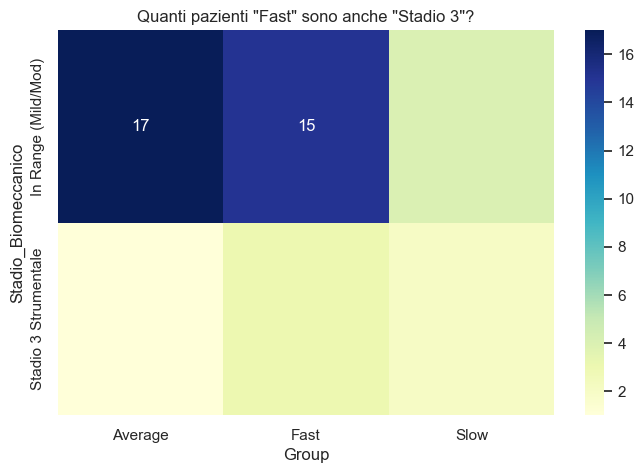

In [10]:
# Creiamo una tabella incrociata
confronto_gruppi = pd.crosstab(df['Stadio_Biomeccanico'], df['Group'])

# Visualizziamola come heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(confronto_gruppi, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Quanti pazienti "Fast" sono anche "Stadio 3"?')
plt.show()

TERZO LIVELLO DI ANALISI: introduzione di nuove variabili

In [11]:
import pandas as pd
import numpy as np

# Carica il dataset pulito
df = pd.read_excel('TABELLAANALISI2.xlsx')

# DELTA STRESS

df['Delta_Step'] = df['HurriedPace_StepLength_Mean'] - df['SelfPace_StepLength_Mean']
df['Delta_ASI']  = df['HurriedPace_StepLength_MeanASI'] - df['SelfPace_StepLength_MeanASI']

print("=== Delta Stress ===")
print(f"Pazienti con riserva motoria (Delta > 0): {(df['Delta_Step'] > 0).sum()}")
print(f"Pazienti senza riserva - Red Flag (Delta ≤ 0): {(df['Delta_Step'] <= 0).sum()}")

#STADIO BIOMECCANICO (Self Pace, da Hass et al. 2012)

def stadio_biomeccanico(row):
    if row['SelfPace_Velocity_cm_sec'] >= 80 and row['SelfPace_StepLength_Mean'] >= 45:
        return 'In Range'
    else:
        return 'Stadio 3'

df['Stadio_Biomeccanico'] = df.apply(stadio_biomeccanico, axis=1)


#PROGRESSION RATE e classificazione Slow/Average/Fast
df['Progression_Rate'] = df['UPDRS_3_TOT'] / df['Anni_Diagnosi']

def classifica_progressione(rate):
    if rate < 2:
        return 'Slow'
    elif rate <= 5:
        return 'Average'
    else:
        return 'Fast'

df['Gruppo'] = df['Progression_Rate'].apply(classifica_progressione)


#FENOTIPO DI PROGRESSIONE

def fenotipo(row):
    bio   = row['Stadio_Biomeccanico']
    delta = row['Delta_Step']
    anni  = row['Anni_Diagnosi']

    if bio == 'In Range' and delta > 0:
        return 'Stabile'
    elif bio == 'In Range' and delta <= 0 and anni < 4:
        return 'Fast Progressor (Early Warning)'
    elif bio == 'Stadio 3' and delta > 0 and anni > 7:
        return 'Slow Progressor (Late Stage)'
    elif bio == 'Stadio 3' and delta <= 0 and anni < 4:
        return 'Fast Progressor (Critico)'
    else:
        return 'Intermedio'   # casi che non rientrano esattamente nella matrice

df['Fenotipo'] = df.apply(fenotipo, axis=1)

print("\n=== Distribuzione Fenotipo ===")
print(df['Fenotipo'].value_counts())
print("\n=== Stadio Biomeccanico ===")
print(df['Stadio_Biomeccanico'].value_counts())

df.to_excel('TABELLAANALISI_fenotipo.xlsx', index=False)
print("\nFile salvato: TABELLAANALISI_fenotipo.xlsx")

=== Delta Stress ===
Pazienti con riserva motoria (Delta > 0): 38
Pazienti senza riserva - Red Flag (Delta ≤ 0): 4

=== Distribuzione Fenotipo ===
Fenotipo
Stabile                         34
Intermedio                       3
Slow Progressor (Late Stage)     3
Fast Progressor (Critico)        2
Name: count, dtype: int64

=== Stadio Biomeccanico ===
Stadio_Biomeccanico
In Range    36
Stadio 3     6
Name: count, dtype: int64

File salvato: TABELLAANALISI_fenotipo.xlsx


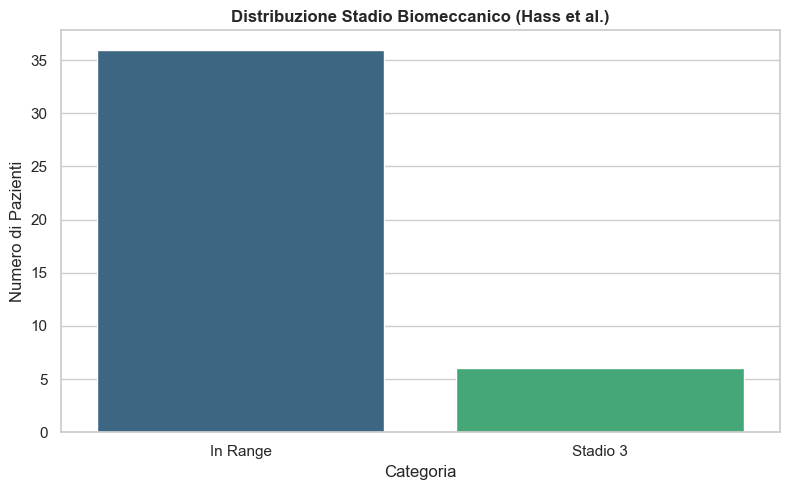

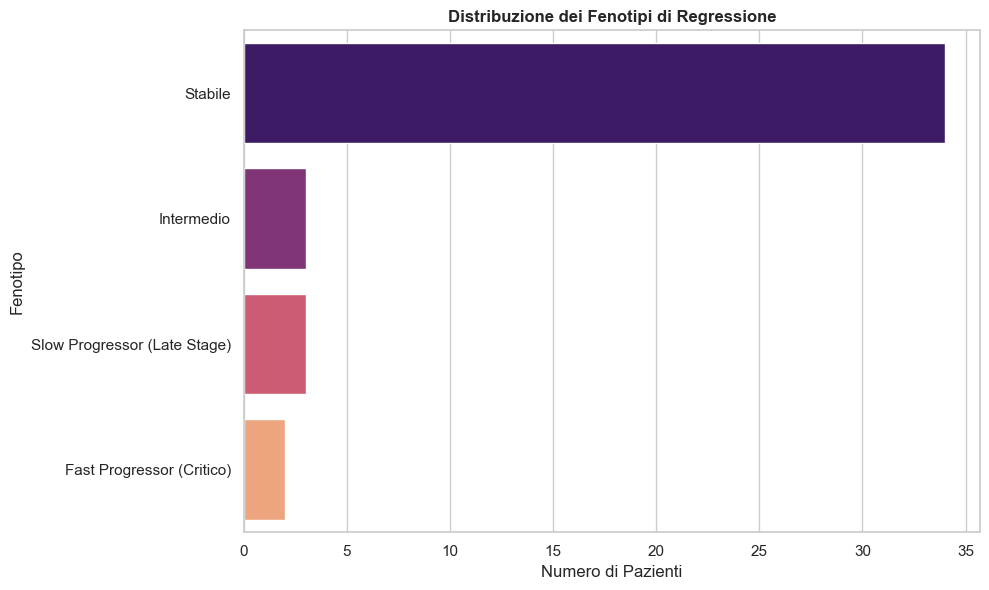

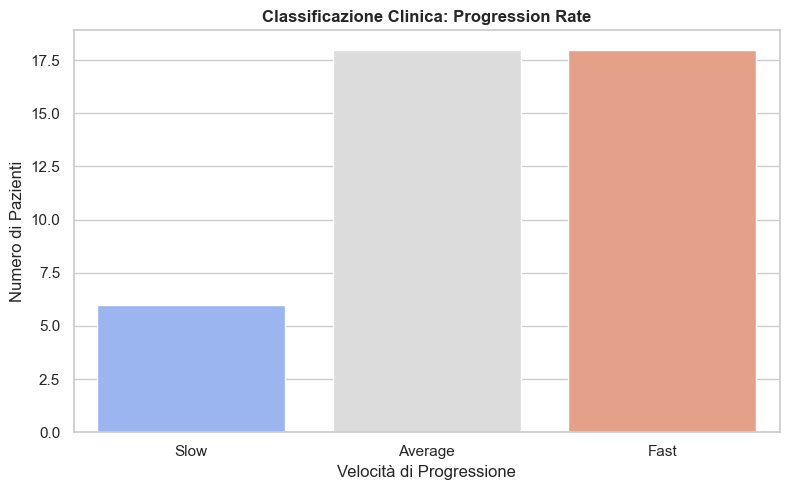


ID SOGGETTO     | STADIO BIO   | GRUPPO RATE  | FENOTIPO FINAL
-------------------------------------------------------------------------------------
NLS187          | Stadio 3     | Fast         | Fast Progressor (Critico)
NLS150          | Stadio 3     | Fast         | Fast Progressor (Critico)
NLS186          | In Range     | Average      | Intermedio
NLS056          | Stadio 3     | Fast         | Intermedio
NLS165          | In Range     | Average      | Intermedio
NLS146          | Stadio 3     | Slow         | Slow Progressor (Late Stage)
NLS161          | Stadio 3     | Average      | Slow Progressor (Late Stage)
NLS143          | Stadio 3     | Slow         | Slow Progressor (Late Stage)
NLS002          | In Range     | Fast         | Stabile
NLS163          | In Range     | Fast         | Stabile
NLS164          | In Range     | Average      | Stabile
NLS166          | In Range     | Average      | Stabile
NLS167          | In Range     | Average      | Stabile
NLS169        

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione estetica
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10})

# CREAZIONE DEI TRE ISTOGRAMMI SEPARATI 

# Istogramma 1: Stadio Biomeccanico
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Stadio_Biomeccanico', palette='viridis')
plt.title('Distribuzione Stadio Biomeccanico (Hass et al.)', fontweight='bold')
plt.xlabel('Categoria')
plt.ylabel('Numero di Pazienti')
plt.tight_layout()
plt.show()

# Istogramma 2: Fenotipo di Regressione
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Fenotipo', palette='magma', order=df['Fenotipo'].value_counts().index)
plt.title('Distribuzione dei Fenotipi di Regressione', fontweight='bold')
plt.xlabel('Numero di Pazienti')
plt.ylabel('Fenotipo')
plt.tight_layout()
plt.show()

# Istogramma 3: Progression Rate (Slow/Average/Fast)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Gruppo', palette='coolwarm', order=['Slow', 'Average', 'Fast'])
plt.title('Classificazione Clinica: Progression Rate', fontweight='bold')
plt.xlabel('Velocità di Progressione')
plt.ylabel('Numero di Pazienti')
plt.tight_layout()
plt.show()

# STAMP DEGLI ID E DESCRITTORI
print("\n" + "="*85)
print(f"{'ID SOGGETTO':<15} | {'STADIO BIO':<12} | {'GRUPPO RATE':<12} | {'FENOTIPO FINAL'}")
print("-" * 85)

# Ordinamento opzionale per Fenotipo per rendere la lista più leggibile
df_report = df.sort_values(by='Fenotipo')

for index, row in df_report.iterrows():
    print(f"{str(row['ID_Soggetto']):<15} | {row['Stadio_Biomeccanico']:<12} | "
          f"{row['Gruppo']:<12} | {row['Fenotipo']}")

print("="*85)

# SALVO questa tabella in un file separato
df[['ID_Soggetto', 'Stadio_Biomeccanico', 'Gruppo', 'Fenotipo']].to_csv('Report_ID_Fenotipi.csv', index=False)
print("\nReport ID salvato con successo in 'Report_ID1_Fenotipi.csv'")

Pazienti nel modello: 42
Distribuzione classi:
Gruppo_cod
0     6
1    18
2    18
Name: count, dtype: int64

Pseudo R² McFadden : 0.097
Log-Likelihood     : -38.076
AIC                : 104.152

=== COEFFICIENTI ===

  Average vs Slow:
    const                                                   coef=0.640   OR=1.897
    SelfPace_Velocity_cm_sec                                coef=0.607   OR=1.835
    Delta_Step                                              coef=-1.160   OR=0.314
    Delta_ASI                                               coef=-0.783   OR=0.457
    Vel_Angolare_Turn_Reale                                 coef=-0.507   OR=0.603
    Instabilita_Tronco_Walk_Cammino a velocità sostenuta    coef=-0.217   OR=0.805
    Hoehn_Yahr                                              coef=-0.212   OR=0.809

  Fast vs Slow:
    const                                                   coef=0.439   OR=1.552
    SelfPace_Velocity_cm_sec                                coef=0.543   OR=1.721
    

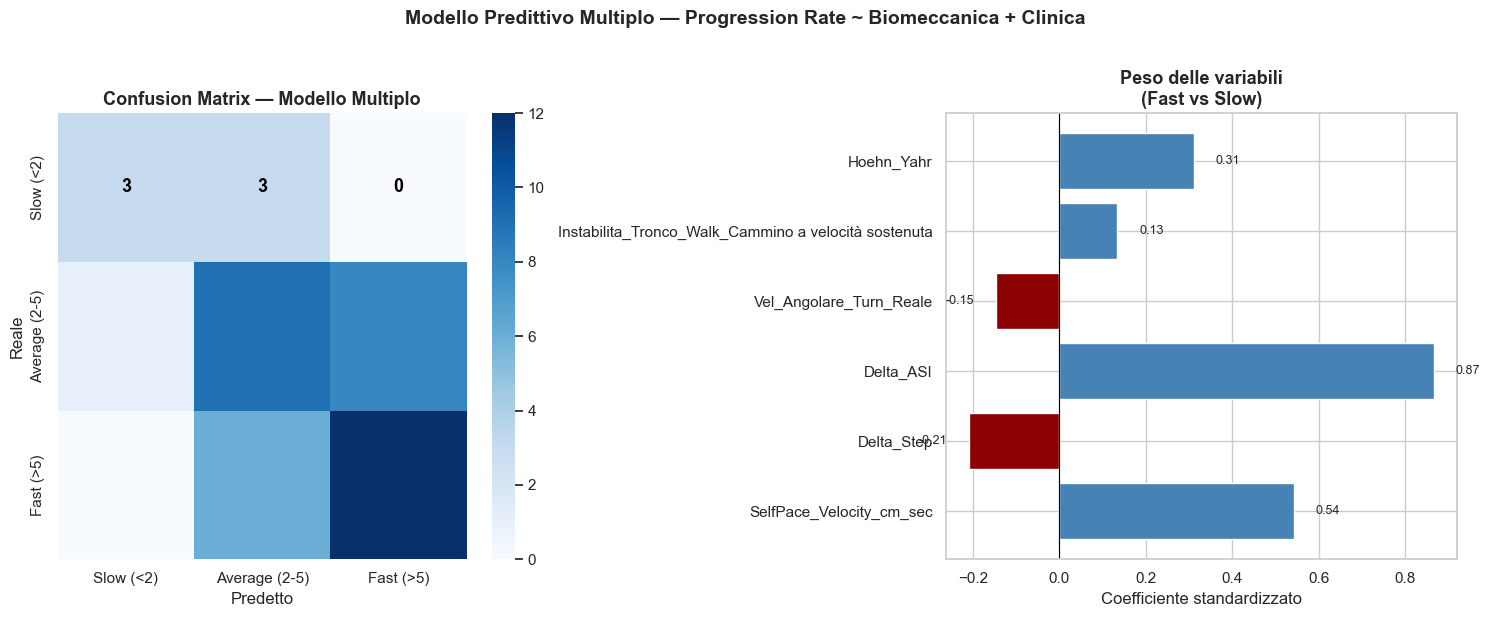

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import MNLogit
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


# VARIABILI PREDITTORIE — ridotte per evitare multicollinearità

predittori = [
    'SelfPace_Velocity_cm_sec',
    'Delta_Step',
    'Delta_ASI',
    'Vel_Angolare_Turn_Reale',
    'Instabilita_Tronco_Walk_Cammino a velocità sostenuta',
    'Hoehn_Yahr'
]


# VARIABILE DIPENDENTE

label_map = {'Slow': 0, 'Average': 1, 'Fast': 2}
df['Gruppo_cod'] = df['Gruppo'].map(label_map)

df_model = df[predittori + ['Gruppo_cod']].dropna()
print(f"Pazienti nel modello: {len(df_model)}")
print(f"Distribuzione classi:\n{df_model['Gruppo_cod'].value_counts().sort_index()}")

X = df_model[predittori]
y = df_model['Gruppo_cod']

# Standardizzazione
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=predittori, index=X.index)
X_sm = sm.add_constant(X_scaled)


# MODELLO con metodo più stabile
model = MNLogit(y.values, X_sm.values).fit(
    method='nm',        # Nelder-Mead: più stabile con campioni piccoli
    maxiter=10000,
    disp=False
)

# Summary semplificato (evita il calcolo delle covarianze che causa l'errore)
print(f"\nPseudo R² McFadden : {model.prsquared:.3f}")
print(f"Log-Likelihood     : {model.llf:.3f}")
print(f"AIC                : {model.aic:.3f}")

# Coefficienti e p-value manuali
params = model.params  # shape: (n_vars, n_classi-1)
print("\n=== COEFFICIENTI ===")
col_names = ['const'] + predittori
class_names = ['Average vs Slow', 'Fast vs Slow']
for i, cname in enumerate(class_names):
    print(f"\n  {cname}:")
    for j, var in enumerate(col_names):
        print(f"    {var:<55} coef={params[j, i]:.3f}   OR={np.exp(params[j, i]):.3f}")


# PREDIZIONE E PERFORMANCE

probs = model.predict(X_sm.values)
y_pred = np.argmax(probs, axis=1)
class_labels = ['Slow (<2)', 'Average (2-5)', 'Fast (>5)']

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y.values, y_pred, target_names=class_labels))


# GRAFICI

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Confusion matrix
cm = confusion_matrix(y.values, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            annot_kws={'size': 13, 'weight': 'bold'}, ax=axes[0])
for text in axes[0].texts:
    text.set_color('black')
axes[0].set_xlabel('Predetto', fontsize=12)
axes[0].set_ylabel('Reale', fontsize=12)
axes[0].set_title('Confusion Matrix — Modello Multiplo', fontsize=13, fontweight='bold')

# Coefficienti Fast vs Slow
coef_fast = pd.Series(params[:, 1], index=col_names).drop('const')
colors_bar = ['darkred' if c < 0 else 'steelblue' for c in coef_fast]
axes[1].barh(coef_fast.index, coef_fast.values, color=colors_bar, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Coefficiente standardizzato', fontsize=12)
axes[1].set_title('Peso delle variabili\n(Fast vs Slow)', fontsize=13, fontweight='bold')
for i, (val, name) in enumerate(zip(coef_fast.values, coef_fast.index)):
    axes[1].text(val + 0.05 if val >= 0 else val - 0.05, i,
                 f'{val:.2f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=9)

plt.suptitle('Modello Predittivo Multiplo — Progression Rate ~ Biomeccanica + Clinica',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('modello_predittivo.png', dpi=150, bbox_inches='tight')
plt.show()

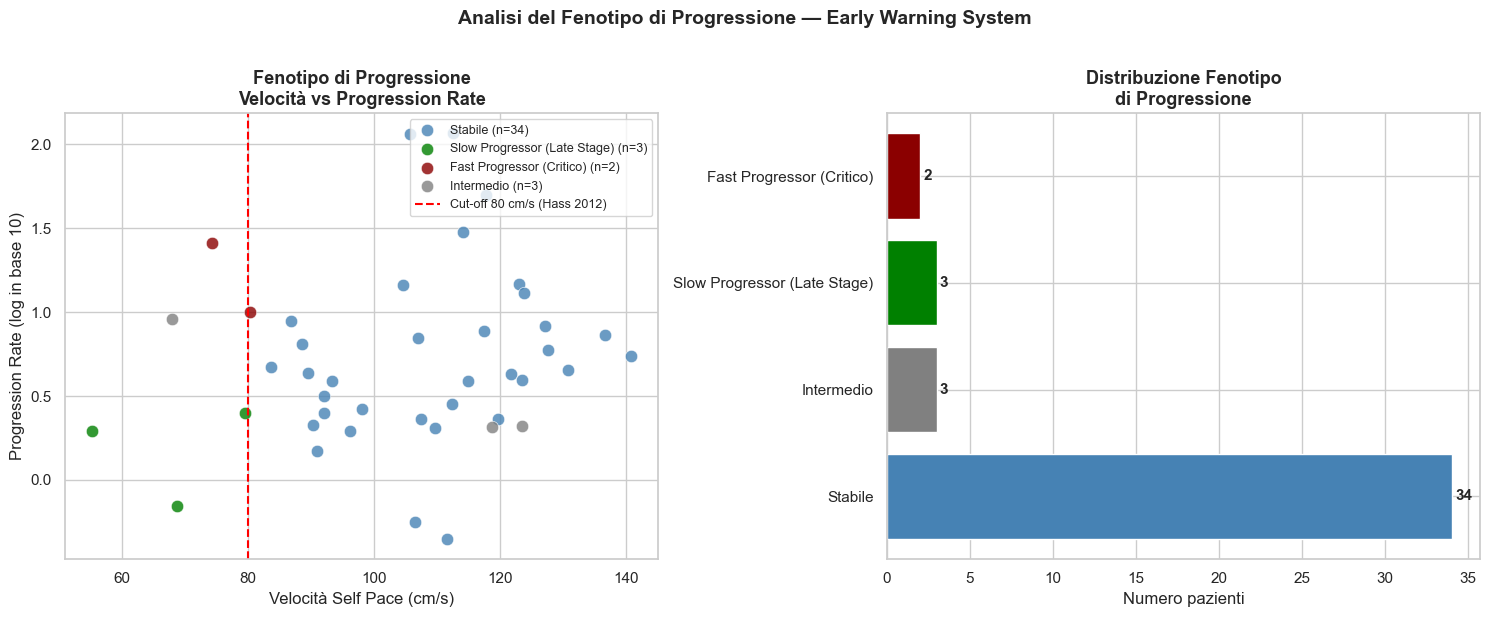


=== FENOTIPO vs GRUPPO ===
Gruppo                        Average  Fast  Slow
Fenotipo                                         
Fast Progressor (Critico)           0     2     0
Intermedio                          2     1     0
Slow Progressor (Late Stage)        1     0     2
Stabile                            15    15     4


In [15]:

# GRAFICO FENOTIPO DI PROGRESSIONE

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Scatter: Velocità vs Progression Rate colorato per Fenotipo ---
colori_fenotipo = {
    'Stabile':                      'steelblue',
    'Fast Progressor (Early Warning)': 'orange',
    'Slow Progressor (Late Stage)': 'green',
    'Fast Progressor (Critico)':    'darkred',
    'Intermedio':                   'gray'
}

ax = axes[0]
for feno, col in colori_fenotipo.items():
    subset = df[df['Fenotipo'] == feno]
    if len(subset) > 0:
        ax.scatter(subset['SelfPace_Velocity_cm_sec'],
                   np.log10(subset['Progression_Rate'].clip(lower=0.1)),
                   c=col, label=f"{feno} (n={len(subset)})",
                   s=80, alpha=0.8, edgecolors='white', linewidth=0.5)

ax.axvline(80, color='red', linestyle='--', linewidth=1.5, label='Cut-off 80 cm/s (Hass 2012)')
ax.set_xlabel('Velocità Self Pace (cm/s)', fontsize=12)
ax.set_ylabel('Progression Rate (log in base 10)', fontsize=12)
ax.set_title('Fenotipo di Progressione\nVelocità vs Progression Rate', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')

# Bar chart distribuzione Fenotipo
ax2 = axes[1]
fenotipo_counts = df['Fenotipo'].value_counts()
bar_colors = [colori_fenotipo.get(f, 'gray') for f in fenotipo_counts.index]
bars = ax2.barh(fenotipo_counts.index, fenotipo_counts.values, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, fenotipo_counts.values):
    ax2.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=11, fontweight='bold')
ax2.set_xlabel('Numero pazienti', fontsize=12)
ax2.set_title('Distribuzione Fenotipo\ndi Progressione', fontsize=13, fontweight='bold')

plt.suptitle('Analisi del Fenotipo di Progressione — Early Warning System',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fenotipo_progressione.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== FENOTIPO vs GRUPPO ===")
print(pd.crosstab(df['Fenotipo'], df['Gruppo']))

Pazienti nel modello integrato: 42
Distribuzione classi:
Gruppo_cod
0     6
1    18
2    18
Name: count, dtype: int64

MODELLO INTEGRATO — Risultati
Pseudo R² McFadden : 0.647
Log-Likelihood     : -14.868
AIC                : 61.737

COEFFICIENTI E ODDS RATIO

  Average vs Slow:
  Variabile                                                  Coef       OR
  ------------------------------------------------------------------------
  Anni_Diagnosi                                            -1.477    0.228  ↓ rischio
  SelfPace_Velocity_cm_sec                                  1.330    3.782  ↑ rischio
  Delta_Step                                                0.654    1.923  ↑ rischio
  Delta_ASI                                                -0.113    0.893  ↓ rischio
  Vel_Angolare_Turn_Reale                                  -2.454    0.086  ↓ rischio
  Instabilita_Tronco_Walk_Cammino a velocità sostenuta     -0.089    0.915  ↓ rischio
  Hoehn_Yahr                                          

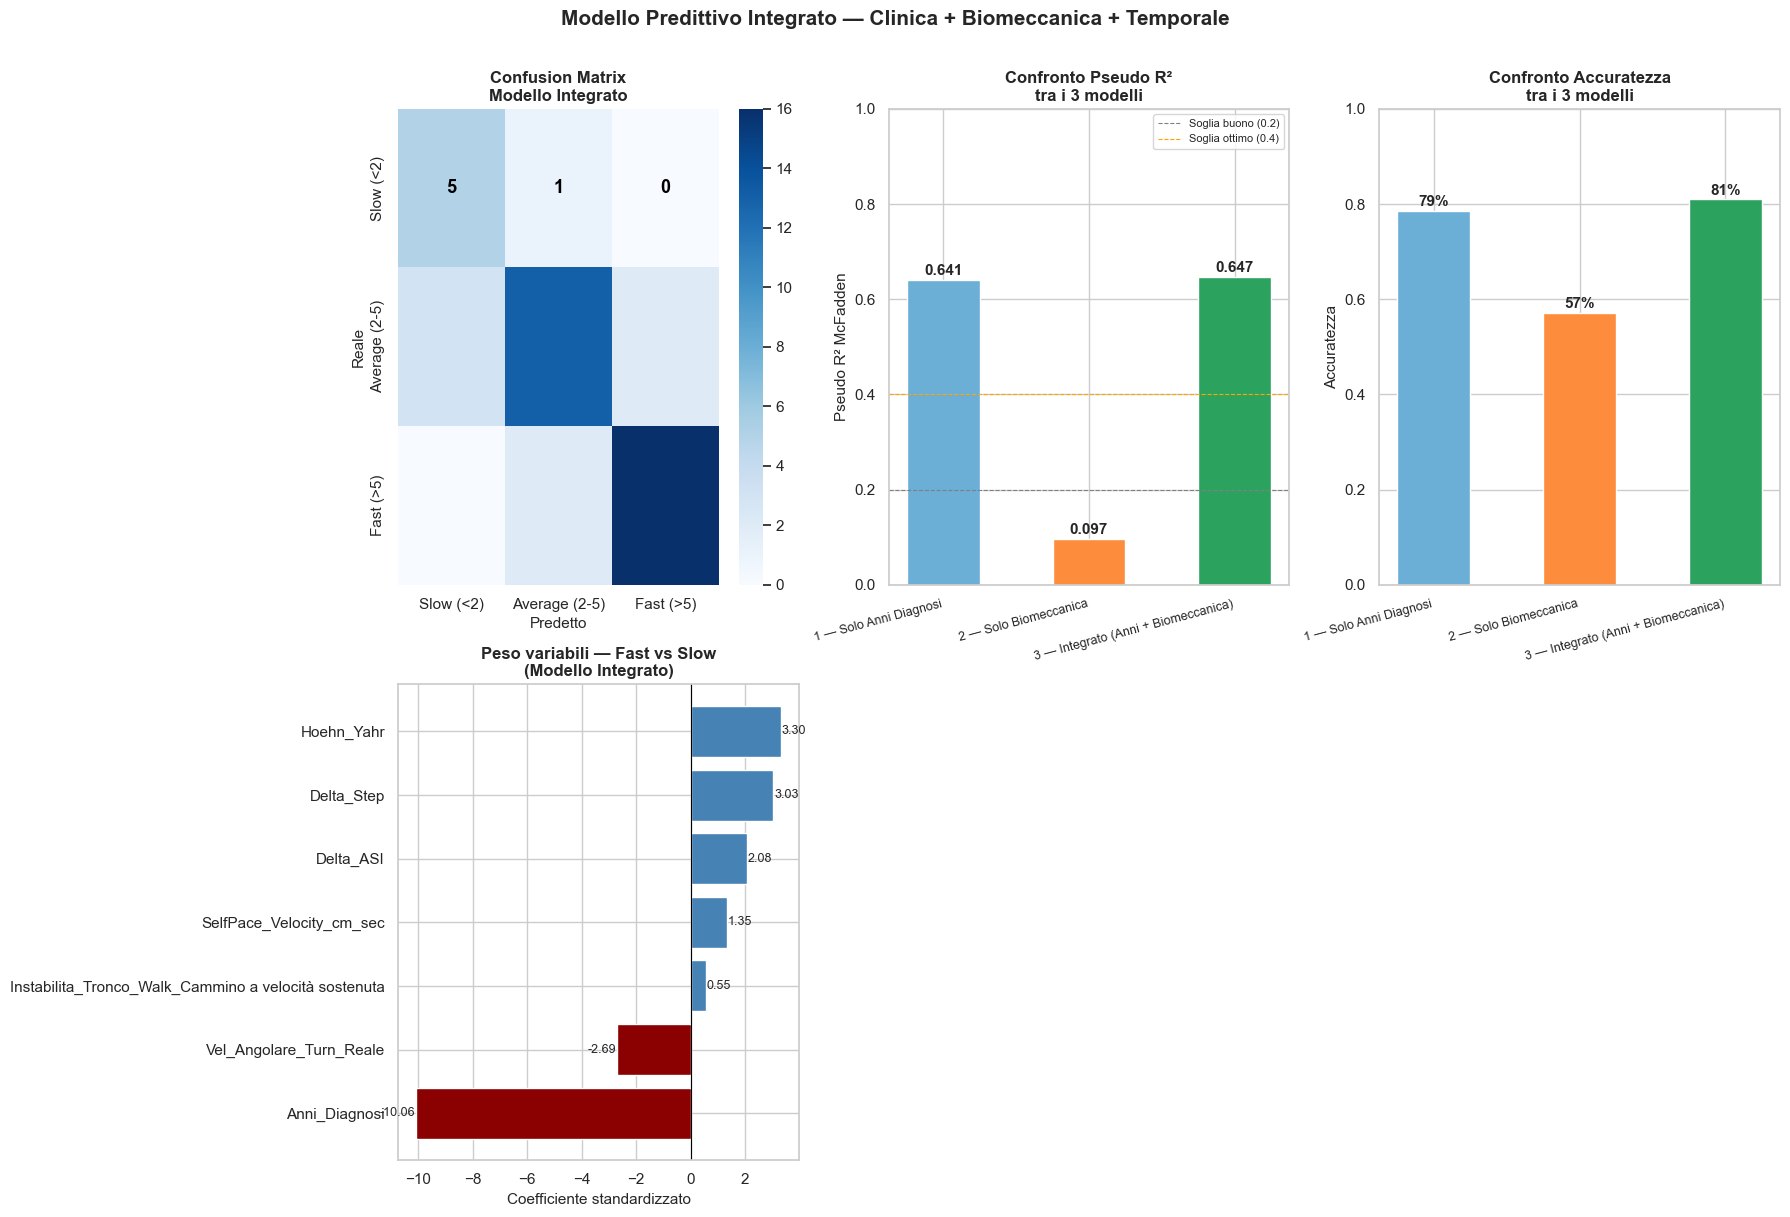

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import MNLogit
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


# VARIABILI — biomeccaniche + cliniche + temporale

predittori_integrati = [
    'Anni_Diagnosi',                      # temporale (il più forte)
    'SelfPace_Velocity_cm_sec',           # velocità naturale
    'Delta_Step',                          # riserva motoria
    'Delta_ASI',                           # asimmetria sotto stress
    'Vel_Angolare_Turn_Reale',            # stabilità posturale
    'Instabilita_Tronco_Walk_Cammino a velocità sostenuta',
    'Hoehn_Yahr'
]

label_map = {'Slow': 0, 'Average': 1, 'Fast': 2}
df['Gruppo_cod'] = df['Gruppo'].map(label_map)

df_model = df[predittori_integrati + ['Gruppo_cod']].dropna()
print(f"Pazienti nel modello integrato: {len(df_model)}")
print(f"Distribuzione classi:\n{df_model['Gruppo_cod'].value_counts().sort_index()}")

X = df_model[predittori_integrati]
y = df_model['Gruppo_cod']

# Standardizzazione
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=predittori_integrati, index=X.index)
X_sm = sm.add_constant(X_scaled)


# MODELLO INTEGRATO

model_int = MNLogit(y.values, X_sm.values).fit(
    method='nm',
    maxiter=10000,
    disp=False
)

probs_int   = model_int.predict(X_sm.values)
y_pred_int  = np.argmax(probs_int, axis=1)
class_labels = ['Slow (<2)', 'Average (2-5)', 'Fast (>5)']

print(f"\n{'='*55}")
print(f"MODELLO INTEGRATO — Risultati")
print(f"{'='*55}")
print(f"Pseudo R² McFadden : {model_int.prsquared:.3f}")
print(f"Log-Likelihood     : {model_int.llf:.3f}")
print(f"AIC                : {model_int.aic:.3f}")

# Coefficienti e OR
params = model_int.params
col_names = ['const'] + predittori_integrati
class_names = ['Average vs Slow', 'Fast vs Slow']

print(f"\n{'='*55}")
print("COEFFICIENTI E ODDS RATIO")
print(f"{'='*55}")
for i, cname in enumerate(class_names):
    print(f"\n  {cname}:")
    print(f"  {'Variabile':<55} {'Coef':>7}  {'OR':>7}")
    print(f"  {'-'*72}")
    for j, var in enumerate(col_names):
        if var == 'const':
            continue
        coef = params[j, i]
        OR   = np.exp(coef)
        direzione = '↑ rischio' if coef > 0 else '↓ rischio'
        print(f"  {var:<55} {coef:>7.3f}  {OR:>7.3f}  {direzione}")

print(f"\n{'='*55}")
print("CLASSIFICATION REPORT")
print(f"{'='*55}")
print(classification_report(y.values, y_pred_int, target_names=class_labels))


# CONFRONTO TRA I 3 MODELLI

from sklearn.metrics import accuracy_score

# Ricrea predizioni modelli precedenti per confronto
# Modello 1: solo Anni Diagnosi
X1 = sm.add_constant(StandardScaler().fit_transform(
    df_model[['Anni_Diagnosi']]))
m1 = MNLogit(y.values, X1).fit(method='nm', maxiter=10000, disp=False)
y1 = np.argmax(m1.predict(X1), axis=1)

# Modello 2: solo biomeccanica
pred_bio = ['SelfPace_Velocity_cm_sec', 'Delta_Step', 'Delta_ASI',
            'Vel_Angolare_Turn_Reale',
            'Instabilita_Tronco_Walk_Cammino a velocità sostenuta',
            'Hoehn_Yahr']
X2 = sm.add_constant(StandardScaler().fit_transform(df_model[pred_bio]))
m2 = MNLogit(y.values, X2).fit(method='nm', maxiter=10000, disp=False)
y2 = np.argmax(m2.predict(X2), axis=1)

confronto = pd.DataFrame({
    'Modello': [
        '1 — Solo Anni Diagnosi',
        '2 — Solo Biomeccanica',
        '3 — Integrato (Anni + Biomeccanica)'
    ],
    'Pseudo R²': [
        round(m1.prsquared, 3),
        round(m2.prsquared, 3),
        round(model_int.prsquared, 3)
    ],
    'Accuratezza': [
        round(accuracy_score(y.values, y1), 3),
        round(accuracy_score(y.values, y2), 3),
        round(accuracy_score(y.values, y_pred_int), 3)
    ],
    'AIC': [
        round(m1.aic, 1),
        round(m2.aic, 1),
        round(model_int.aic, 1)
    ]
})
print(f"\n{'='*55}")
print("CONFRONTO TRA MODELLI")
print(f"{'='*55}")
print(confronto.to_string(index=False))


# GRAFICI

fig = plt.figure(figsize=(18, 12))

# confusion Matrix modello integrato 
ax1 = fig.add_subplot(2, 3, 1)
cm = confusion_matrix(y.values, y_pred_int)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            annot_kws={'size': 13, 'weight': 'bold'}, ax=ax1)
for text in ax1.texts:
    text.set_color('black')
ax1.set_xlabel('Predetto', fontsize=11)
ax1.set_ylabel('Reale', fontsize=11)
ax1.set_title('Confusion Matrix\nModello Integrato', fontsize=12, fontweight='bold')

# Confronto Pseudo R² 
ax2 = fig.add_subplot(2, 3, 2)
colors_r2 = ['#6baed6', '#fd8d3c', '#2ca25f']
bars = ax2.bar(confronto['Modello'], confronto['Pseudo R²'],
               color=colors_r2, edgecolor='white', width=0.5)
for bar, val in zip(bars, confronto['Pseudo R²']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('Pseudo R² McFadden', fontsize=11)
ax2.set_title('Confronto Pseudo R²\ntra i 3 modelli', fontsize=12, fontweight='bold')
ax2.set_xticklabels(confronto['Modello'], rotation=15, ha='right', fontsize=9)
ax2.set_ylim(0, 1)
ax2.axhline(0.2, color='gray', linestyle='--', linewidth=0.8, label='Soglia buono (0.2)')
ax2.axhline(0.4, color='orange', linestyle='--', linewidth=0.8, label='Soglia ottimo (0.4)')
ax2.legend(fontsize=8)

# Confronto Accuratezza 
ax3 = fig.add_subplot(2, 3, 3)
bars2 = ax3.bar(confronto['Modello'], confronto['Accuratezza'],
                color=colors_r2, edgecolor='white', width=0.5)
for bar, val in zip(bars2, confronto['Accuratezza']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.0%}', ha='center', fontsize=11, fontweight='bold')
ax3.set_ylabel('Accuratezza', fontsize=11)
ax3.set_title('Confronto Accuratezza\ntra i 3 modelli', fontsize=12, fontweight='bold')
ax3.set_xticklabels(confronto['Modello'], rotation=15, ha='right', fontsize=9)
ax3.set_ylim(0, 1)

# Peso variabili Fast vs Slow (modello integrato)
ax4 = fig.add_subplot(2, 3, 4)
coef_fast = pd.Series(params[:, 1], index=col_names).drop('const')
coef_fast = coef_fast.sort_values()
colors_bar = ['darkred' if c < 0 else 'steelblue' for c in coef_fast]
ax4.barh(coef_fast.index, coef_fast.values, color=colors_bar, edgecolor='white')
ax4.axvline(0, color='black', linewidth=0.8)
for i, (val, name) in enumerate(zip(coef_fast.values, coef_fast.index)):
    ax4.text(val + 0.03 if val >= 0 else val - 0.03, i,
             f'{val:.2f}', va='center',
             ha='left' if val >= 0 else 'right', fontsize=9)
ax4.set_xlabel('Coefficiente standardizzato', fontsize=11)
ax4.set_title('Peso variabili — Fast vs Slow\n(Modello Integrato)', fontsize=12, fontweight='bold')


plt.suptitle('Modello Predittivo Integrato — Clinica + Biomeccanica + Temporale',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('modello_integrato.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# REPORT INDIVIDUALE PER PAZIENTE


# Probabilità predette per ogni paziente
probs_df = pd.DataFrame(
    probs_int,
    columns=['P_Slow', 'P_Average', 'P_Fast'],
    index=df_model.index
)

# Classe predetta
probs_df['Classe_Predetta'] = pd.Categorical.from_codes(
    y_pred_int, categories=['Slow', 'Average', 'Fast']
)

# Classe reale
probs_df['Classe_Reale'] = pd.Categorical.from_codes(
    y.values, categories=['Slow', 'Average', 'Fast']
)

# Corretta classificazione
probs_df['Corretto'] = probs_df['Classe_Predetta'] == probs_df['Classe_Reale']

# Aggiungi ID paziente e variabili chiave
report = df_model[predittori_integrati].copy()
report = report.join(probs_df)
# Usa ID_Soggetto dal dataframe originale
report.insert(0, 'ID', df.loc[df_model.index, 'ID_Soggetto'].values)

# Fenotipo se disponibile
if 'Fenotipo' in df.columns:
    report['Fenotipo'] = df.loc[df_model.index, 'Fenotipo'].values

if 'Progression_Rate' in df.columns:
    report['Progression_Rate'] = df.loc[df_model.index, 'Progression_Rate'].values

# Formattazione probabilità in percentuale
report['P_Slow_%']    = (report['P_Slow']    * 100).round(1)
report['P_Average_%'] = (report['P_Average'] * 100).round(1)
report['P_Fast_%']    = (report['P_Fast']    * 100).round(1)


# STAMPA A SCHERMO

print("=" * 110)
print("REPORT PREDITTIVO INDIVIDUALE — MODELLO INTEGRATO")
print("=" * 110)
print(f"{'ID':<12} {'Anni_Diag':>9} {'H&Y':>5} {'Prog_Rate':>10} "
      f"{'P_Slow%':>8} {'P_Avg%':>8} {'P_Fast%':>8} "
      f"{'Classe_Reale':<14} {'Classe_Predetta':<16} {'OK':>5} {'Fenotipo'}")
print("-" * 110)

for _, row in report.iterrows():
    ok_sym = '✓' if row['Corretto'] else '✗'
    feno   = row['Fenotipo'] if 'Fenotipo' in report.columns else '-'
    pr     = f"{row['Progression_Rate']:.2f}" if 'Progression_Rate' in report.columns else '-'
    hy     = f"{row['Hoehn_Yahr']:.1f}"
    anni   = f"{row['Anni_Diagnosi']:.1f}"

    print(f"{str(row['ID']):<12} {anni:>9} {hy:>5} {pr:>10} "
          f"{row['P_Slow_%']:>7.1f}% {row['P_Average_%']:>7.1f}% {row['P_Fast_%']:>7.1f}% "
          f"{str(row['Classe_Reale']):<14} {str(row['Classe_Predetta']):<16} "
          f"{ok_sym:>5}  {feno}")

print("-" * 110)
print(f"\nTotale pazienti: {len(report)}")
print(f"Classificati correttamente: {report['Corretto'].sum()} "
      f"({report['Corretto'].mean()*100:.1f}%)")
print(f"Errori: {(~report['Corretto']).sum()}")


# PAZIENTI A RISCHIO — Fast con alta probabilità

print("\n" + "=" * 80)
print("PAZIENTI AD ALTO RISCHIO — P(Fast) > 70%")
print("=" * 80)
alto_rischio = report[report['P_Fast_%'] > 70].sort_values('P_Fast_%', ascending=False)
if len(alto_rischio) > 0:
    for _, row in alto_rischio.iterrows():
        feno = row['Fenotipo'] if 'Fenotipo' in report.columns else '-'
        print(f"  {str(row['ID']):<12}  P(Fast)={row['P_Fast_%']:.1f}%  "
              f"Anni={row['Anni_Diagnosi']:.1f}  H&Y={row['Hoehn_Yahr']:.1f}  "
              f"Reale={row['Classe_Reale']}  Fenotipo={feno}")
else:
    print("  Nessun paziente con P(Fast) > 70%")


# PAZIENTI MAL CLASSIFICATI — analisi errori

print("\n" + "=" * 80)
print("PAZIENTI MAL CLASSIFICATI")
print("=" * 80)
errori = report[~report['Corretto']].sort_values('P_Fast_%', ascending=False)
for _, row in errori.iterrows():
    feno = row['Fenotipo'] if 'Fenotipo' in report.columns else '-'
    print(f"  {str(row['ID']):<12}  Reale={str(row['Classe_Reale']):<8}  "
          f"Predetto={str(row['Classe_Predetta']):<8}  "
          f"P_Slow={row['P_Slow_%']:.1f}%  "
          f"P_Avg={row['P_Average_%']:.1f}%  "
          f"P_Fast={row['P_Fast_%']:.1f}%  "
          f"Anni={row['Anni_Diagnosi']:.1f}  Fenotipo={feno}")


# SALVA EXCEL

cols_excel = ['ID', 'Anni_Diagnosi', 'Hoehn_Yahr', 'Progression_Rate',
              'P_Slow_%', 'P_Average_%', 'P_Fast_%',
              'Classe_Reale', 'Classe_Predetta', 'Corretto', 'Fenotipo']
cols_excel = [c for c in cols_excel if c in report.columns]

report[cols_excel].to_excel('report_individuale.xlsx', index=False)
print("\n✓ File salvato: report_individuale.xlsx")

REPORT PREDITTIVO INDIVIDUALE — MODELLO INTEGRATO
ID           Anni_Diag   H&Y  Prog_Rate  P_Slow%   P_Avg%  P_Fast% Classe_Reale   Classe_Predetta     OK Fenotipo
--------------------------------------------------------------------------------------------------------------
NLS002             2.3   2.0       7.76     0.0%     1.5%    98.5% Fast           Fast                 ✓  Stabile
NLS005             2.7   2.0       8.89     0.1%    13.0%    86.8% Fast           Fast                 ✓  Stabile
NLS022             5.4   2.5       5.91     6.8%    63.8%    29.4% Fast           Average              ✗  Stabile
NLS036            18.4   2.5       2.51    82.0%    18.0%     0.0% Average        Slow                 ✗  Stabile
NLS056             3.5   2.0       9.14     0.1%     1.2%    98.7% Fast           Fast                 ✓  Intermedio
NLS121             1.6   3.0       7.01     0.0%     0.8%    99.2% Fast           Fast                 ✓  Stabile
NLS130             3.4   2.5       6.4

In [18]:
import pandas as pd

# 1. Definizione dei dati
data = [
    ["NLS002", 2.3, 2.0, "In Range", "Fast", "Fast", "0% / 1.5% / 98.5%", "✓", "Stabile"],
    ["NLS005", 2.7, 2.0, "In Range", "Fast", "Fast", "0.1% / 13% / 86.8%", "✓", "Stabile"],
    ["NLS022", 5.4, 2.5, "In Range", "Fast", "Average", "6.8% / 63.8% / 29.4%", "✗", "Stabile"],
    ["NLS036", 18.4, 2.5, "In Range", "Average", "Slow", "82% / 18% / 0%", "✗", "Stabile"],
    ["NLS056", 3.5, 2.0, "Stadio 3", "Fast", "Fast", "0.1% / 1.2% / 98.7%", "✓", "Intermedio"],
    ["NLS121", 1.6, 3.0, "In Range", "Fast", "Fast", "0% / 0.8% / 99.2%", "✓", "Stabile"],
    ["NLS130", 3.4, 2.5, "In Range", "Fast", "Fast", "0.3% / 27% / 72.7%", "✓", "Stabile"],
    ["NLS135", 0.4, 3.0, "In Range", "Fast", "Fast", "0% / 0% / 100%", "✓", "Stabile"],
    ["NLS139", 2.3, 2.0, "In Range", "Fast", "Fast", "0% / 0.1% / 99.9%", "✓", "Stabile"],
    ["NLS140", 10.3, 3.0, "In Range", "Average", "Average", "3.9% / 95.7% / 0.5%", "✓", "Stabile"],
    ["NLS141", 8.3, 3.0, "In Range", "Average", "Average", "0.3% / 97.7% / 2%", "✓", "Stabile"],
    ["NLS142", 12.3, 2.0, "In Range", "Slow", "Slow", "79.2% / 20.8% / 0%", "✓", "Stabile"],
    ["NLS143", 18.4, 2.5, "Stadio 3", "Slow", "Slow", "86.1% / 13.9% / 0%", "✓", "Slow Progressor (Late Stage)"],
    ["NLS146", 14.4, 2.0, "Stadio 3", "Slow", "Slow", "71% / 29% / 0%", "✓", "Slow Progressor (Late Stage)"],
    ["NLS148", 0.3, 2.0, "In Range", "Fast", "Fast", "0% / 0% / 100%", "✓", "Stabile"],
    ["NLS149", 19.4, 2.5, "In Range", "Slow", "Slow", "85.6% / 14.4% / 0%", "✓", "Stabile"],
    ["NLS150", 1.4, 2.5, "Stadio 3", "Fast", "Fast", "0% / 1.9% / 98.1%", "✓", "Fast Progressor (Critico)"],
    ["NLS152", 4.4, 2.0, "In Range", "Average", "Fast", "2.3% / 37.1% / 60.6%", "✗", "Stabile"],
    ["NLS153", 9.4, 2.0, "In Range", "Average", "Slow", "58.1% / 41.9% / 0%", "✗", "Stabile"],
    ["NLS154", 0.4, 2.0, "In Range", "Fast", "Fast", "0% / 0.1% / 99.9%", "✓", "Stabile"],
    ["NLS155", 13.5, 2.0, "In Range", "Slow", "Slow", "85% / 15% / 0%", "✓", "Stabile"],
    ["NLS157", 9.5, 2.0, "In Range", "Average", "Average", "2.6% / 97.3% / 0.1%", "✓", "Stabile"],
    ["NLS158", 6.5, 1.0, "In Range", "Average", "Average", "11.6% / 86.9% / 1.6%", "✓", "Stabile"],
    ["NLS160", 2.5, 2.0, "In Range", "Fast", "Fast", "0% / 1.3% / 98.6%", "✓", "Stabile"],
    ["NLS161", 15.6, 3.0, "Stadio 3", "Average", "Average", "0.9% / 99.1% / 0%", "✓", "Slow Progressor (Late Stage)"],
    ["NLS163", 0.5, 2.0, "In Range", "Fast", "Fast", "0% / 0.1% / 100%", "✓", "Stabile"],
    ["NLS164", 4.6, 2.0, "In Range", "Average", "Fast", "0.2% / 17.3% / 82.5%", "✗", "Stabile"],
    ["NLS165", 15.6, 2.5, "In Range", "Average", "Average", "22.5% / 77.5% / 0%", "✓", "Intermedio"],
    ["NLS166", 6.6, 2.5, "In Range", "Average", "Average", "10.2% / 85% / 4.8%", "✓", "Stabile"],
    ["NLS167", 5.6, 2.0, "In Range", "Average", "Average", "24.3% / 75% / 0.6%", "✓", "Stabile"],
    ["NLS169", 2.6, 2.0, "In Range", "Fast", "Fast", "0.7% / 2% / 97.4%", "✓", "Stabile"],
    ["NLS170", 3.7, 1.0, "In Range", "Fast", "Average", "1.8% / 52.9% / 45.2%", "✗", "Stabile"],
    ["NLS172", 17.8, 2.0, "In Range", "Slow", "Average", "32.6% / 67.4% / 0%", "✗", "Stabile"],
    ["NLS173", 9.8, 2.0, "In Range", "Average", "Average", "1% / 99% / 0%", "✓", "Stabile"],
    ["NLS174", 5.8, 2.0, "In Range", "Average", "Average", "6.9% / 86.3% / 6.9%", "✓", "Stabile"],
    ["NLS182", 3.1, 2.0, "In Range", "Average", "Slow", "77.5% / 12.8% / 9.7%", "✗", "Stabile"],
    ["NLS183", 1.1, 2.5, "In Range", "Fast", "Fast", "0% / 0.3% / 99.7%", "✓", "Stabile"],
    ["NLS184", 9.1, 2.0, "In Range", "Average", "Average", "40% / 60% / 0%", "✓", "Stabile"],
    ["NLS185", 9.2, 2.5, "In Range", "Average", "Average", "6.2% / 90.9% / 2.8%", "✓", "Stabile"],
    ["NLS186", 8.2, 1.0, "In Range", "Average", "Average", "45% / 55% / 0%", "✓", "Intermedio"],
    ["NLS187", 3.3, 4.0, "Stadio 3", "Fast", "Fast", "3.2% / 31.3% / 65.5%", "✓", "Fast Progressor (Critico)"],
    ["WPD015", 4.0, 2.0, "In Range", "Fast", "Fast", "0% / 1% / 99%", "✓", "Stabile"]
]

#Creazione delle colonne
columns = [
    "ID Soggetto", "Anni Diag", "H&Y", "Stadio Bio",
    "Gruppo (Reale)", "Predizione", "Probabilità (S/A/F)", "OK", "Fenotipo Finale"
]

#Creazione del DataFrame
df = pd.DataFrame(data, columns=columns)

#Ordinamento per ID Soggetto
df = df.sort_values(by="ID Soggetto")

#Esportazione in Excel
output_file = "Analisi_Integrata_Parkinson.xlsx"
df.to_excel(output_file, index=False)

print(f"File '{output_file}' creato con successo!")

File 'Analisi_Integrata_Parkinson.xlsx' creato con successo!


In [19]:
print(output_file)

Analisi_Integrata_Parkinson.xlsx
